In [32]:
import pandas as pd
import matplotlib.pyplot as plt


ModelGPT 5.2

ALTE SORTIERUNG (BACKUP)


run 1 = claude donnet-4-6 temp = 1
run 2 = claude donnet-4-6 temp = 0.5
run 3 = claude donnet-4-6 temp = 0.0
run 4 = gpt 5.2 temp defaul 
run 5 = gpt 5.2 temp defaul 

run 6 = gpt 5.2 temp = 0
run 7 = gpt 5.2 temp = 0.5
run 8 = gpt 5.2 temp = 1


In [33]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [34]:
df = ev.build_results("results")

/Users/s.franke/Development/master_clean/experiments/evaluation.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[err_col] = df.apply(calc_row, axis=1, args=(domain, pred_col))
/Users/s.franke/Development/master_clean/experiments/evaluation.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.apply(calc_row, axis=1, args=(err_col, conf_col))


In [35]:
df

,A,A_1,A_1_conf,A_1_conf_error,A_1_error,A_2,A_2_conf,A_2_conf_error,A_2_error,A_3,...,E_6_conf_error,E_6_error,E_7,E_7_conf,E_7_conf_error,E_7_error,E_8,E_8_conf,E_8_conf_error,E_8_error
call_nr,,,,,,,,,,,,,,,,,,,,,
1,1,1,0.40,0.60,0,1,0.40,0.60,0,1,...,0.58,0,0,0.20,0.20,1,0,0.20,0.20,1
2,1,1,0.80,0.20,0,1,0.80,0.20,0,1,...,0.70,0,1,0.22,0.78,0,1,0.42,0.58,0
3,1,1,0.70,0.30,0,2,0.50,0.50,1,2,...,0.42,0,1,0.55,0.45,0,1,0.55,0.45,0
4,1,1,0.50,0.50,0,1,0.50,0.50,0,1,...,0.10,1,0,0.10,0.10,1,0,0.10,0.10,1
5,1,1,0.60,0.40,0,1,0.60,0.40,0,1,...,0.30,1,0,0.15,0.30,2,0,0.66,1.32,2
6,3,0,0.20,0.60,3,3,0.60,0.40,0,3,...,0.75,0,0,0.05,0.95,0,0,0.25,0.75,0
7,3,3,0.85,0.15,0,3,0.85,0.15,0,3,...,1.10,2,2,0.60,1.20,2,2,0.55,1.10,2
8,1,1,0.60,0.40,0,1,0.60,0.40,0,1,...,1.40,2,2,0.62,1.24,2,2,0.55,1.10,2
9,3,2,0.82,1.64,2,2,0.82,1.64,2,2,...,0.20,1,0,0.12,0.12,1,1,0.36,0.64,0


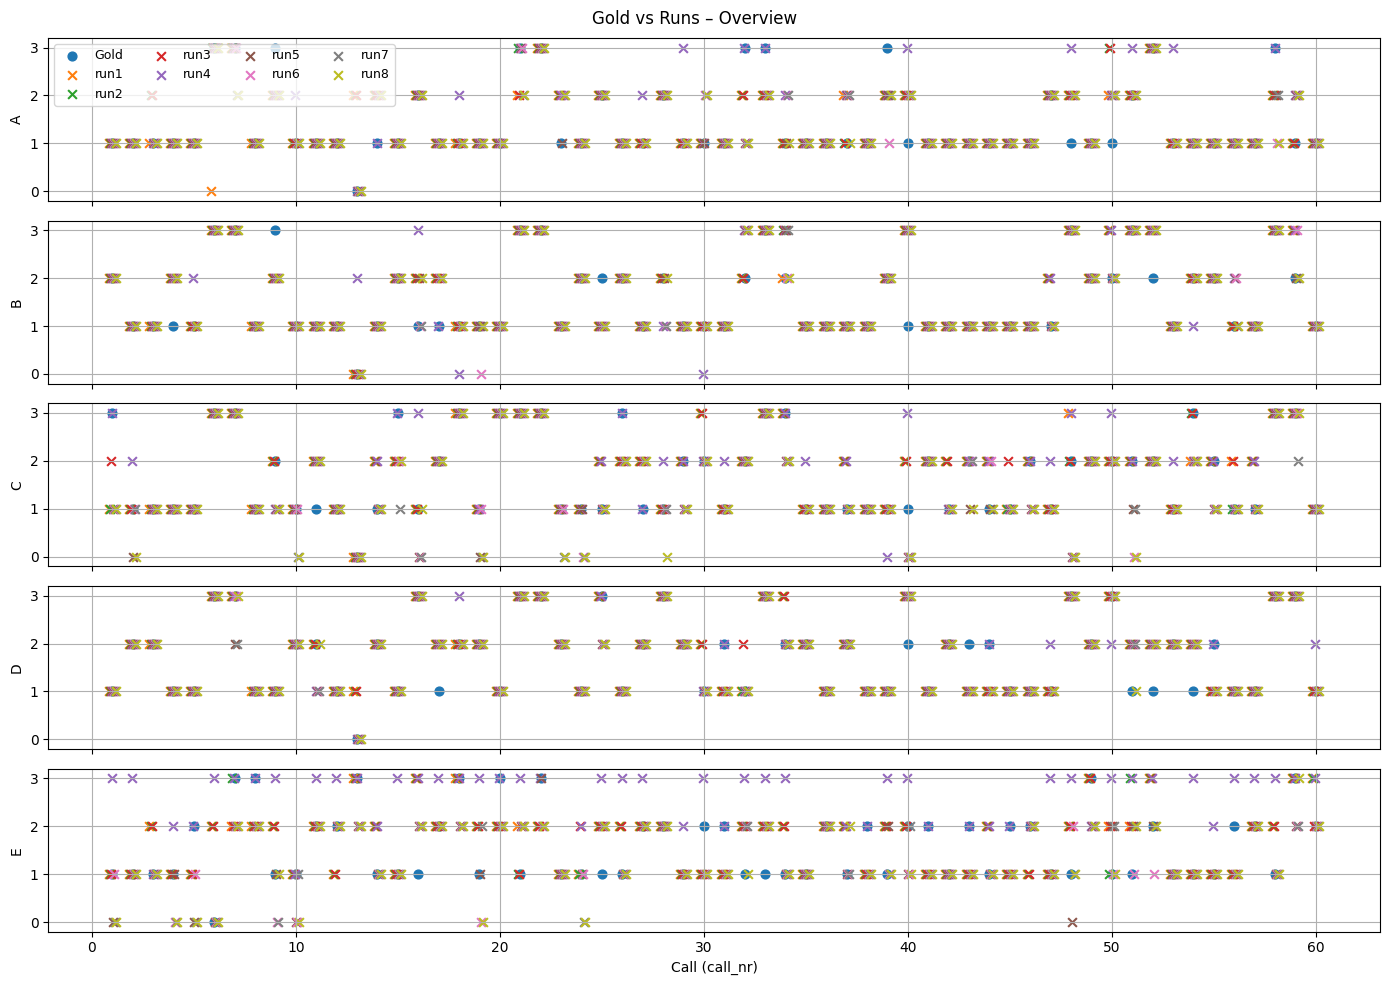

In [36]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [37]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.437500,0.30,26.25,0.580963
1,conf_error,1,B,60,0.356667,0.28,21.40,0.499183
2,conf_error,1,C,60,0.474333,0.45,28.46,0.568709
3,conf_error,1,D,60,0.299333,0.18,17.96,0.391105
4,conf_error,1,E,60,0.593667,0.60,35.62,0.666751
...,...,...,...,...,...,...,...,...
75,error,8,A,60,0.383333,0.00,23.00,0.866025
76,error,8,B,60,0.166667,0.00,10.00,0.483046
77,error,8,C,60,0.483333,0.00,29.00,0.885061
78,error,8,D,60,0.166667,0.00,10.00,0.447214


In [38]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.437500,0.356667,0.474333,0.299333,0.593667
2,0.431333,0.364833,0.447333,0.304000,0.597000
3,0.444500,0.362833,0.445333,0.313667,0.593500
4,0.378833,0.354000,0.432000,0.274667,0.909167
5,0.414667,0.367167,0.513833,0.379667,0.592833
6,0.450333,0.360667,0.519333,0.360667,0.593167
7,0.482667,0.352167,0.512833,0.387333,0.572500
8,0.477000,0.330333,0.515167,0.349833,0.560500


In [39]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.383333,0.200000,0.350000,0.200000,0.683333
2,0.316667,0.216667,0.283333,0.200000,0.633333
3,0.350000,0.216667,0.300000,0.216667,0.666667
4,0.350000,0.366667,0.366667,0.200000,0.983333
5,0.283333,0.200000,0.416667,0.233333,0.583333
6,0.366667,0.216667,0.416667,0.200000,0.600000
7,0.400000,0.183333,0.483333,0.233333,0.616667
8,0.383333,0.166667,0.483333,0.166667,0.583333


In [40]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.432300,129.69,1.90
1,conf_error,2,300,0.428900,128.67,1.90
2,conf_error,3,300,0.431967,129.59,1.90
3,conf_error,4,300,0.469733,140.92,1.90
4,conf_error,5,300,0.453633,136.09,1.86
5,conf_error,6,300,0.456833,137.05,2.22
6,conf_error,7,300,0.461500,138.45,2.22
7,conf_error,8,300,0.446567,133.97,2.22
8,error,1,300,0.363333,109.00,3.00
9,error,2,300,0.330000,99.00,3.00


In [41]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,109,129.69
1,2,99,128.67
2,3,105,129.59
3,4,136,140.92
4,5,103,136.09
5,6,108,137.05
6,7,115,138.45
7,8,107,133.97


In [42]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.354167,170,0.439604,211.01
1,B,0.220833,106,0.356083,170.92
2,C,0.387500,186,0.482521,231.61
3,D,0.206250,99,0.333646,160.15
4,E,0.668750,321,0.626542,300.74
